# 01 - Data Exploration: Car Plate Detection

In this notebook, we will:
1. Understand the dataset structure
2. Parse and analyze the Pascal VOC XML annotations
3. Visualize sample images with bounding boxes
4. Analyze bounding box statistics (size, aspect ratio, position)
5. Identify potential challenges for object detection

## 1. Setup & Imports

In [13]:
import os
import glob
import random
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
random.seed(42)

print('All imports successful!')

All imports successful!


## 2. Explore the Dataset Structure

In [14]:
# =============================================
# UPDATE THIS PATH to match your folder layout
# =============================================
DATA_DIR = os.path.join('..', 'data', 'raw')

# List contents of the data directory
print('Contents of data/raw/:')
for item in os.listdir(DATA_DIR):
    full_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(full_path):
        count = len(os.listdir(full_path))
        print(f'  📁 {item}/ ({count} files)')
    else:
        print(f'  📄 {item}')

Contents of data/raw/:
  📄 .DS_Store
  📁 images/ (433 files)
  📄 .gitkeep
  📁 annotations/ (433 files)


In [15]:
# Find image and annotation directories
# The dataset typically has 'images' and 'annotations' folders
# Adjust these paths if your structure is different

IMAGE_DIR = os.path.join(DATA_DIR, 'images')
ANNOT_DIR = os.path.join(DATA_DIR, 'annotations')

# If the folders don't exist, try to auto-detect
if not os.path.exists(IMAGE_DIR) or not os.path.exists(ANNOT_DIR):
    print('Default paths not found. Scanning for image and XML files...')
    all_files = []
    for root, dirs, files in os.walk(DATA_DIR):
        for f in files:
            all_files.append(os.path.join(root, f))
    
    image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    xml_files = [f for f in all_files if f.lower().endswith('.xml')]
    
    if image_files:
        IMAGE_DIR = os.path.dirname(image_files[0])
    if xml_files:
        ANNOT_DIR = os.path.dirname(xml_files[0])
    
    print(f'Found images in: {IMAGE_DIR}')
    print(f'Found annotations in: {ANNOT_DIR}')

# Get lists of files
image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.[pjP][npN][gG]*')))
annot_files = sorted(glob.glob(os.path.join(ANNOT_DIR, '*.xml')))

print(f'\nTotal images: {len(image_files)}')
print(f'Total annotations: {len(annot_files)}')
print(f'\nSample image filenames: {[os.path.basename(f) for f in image_files[:5]]}')
print(f'Sample annotation filenames: {[os.path.basename(f) for f in annot_files[:5]]}')


Total images: 433
Total annotations: 433

Sample image filenames: ['Cars0.png', 'Cars1.png', 'Cars10.png', 'Cars100.png', 'Cars101.png']
Sample annotation filenames: ['Cars0.xml', 'Cars1.xml', 'Cars10.xml', 'Cars100.xml', 'Cars101.xml']


## 3. Parse Pascal VOC XML Annotations

In [16]:
def parse_voc_annotation(xml_path):
    """Parse a Pascal VOC XML annotation file.
    
    Returns a dict with image info and list of bounding boxes.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get image info
    filename = root.find('filename').text
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    depth = int(size.find('depth').text) if size.find('depth') is not None else 3
    
    # Get bounding boxes
    boxes = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))
        
        boxes.append({
            'label': label,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax,
            'box_width': xmax - xmin,
            'box_height': ymax - ymin,
            'box_area': (xmax - xmin) * (ymax - ymin)
        })
    
    return {
        'filename': filename,
        'width': width,
        'height': height,
        'depth': depth,
        'boxes': boxes,
        'num_boxes': len(boxes)
    }

# Let's look at one annotation to understand the format
print('Sample XML content:')
print('=' * 50)
with open(annot_files[0], 'r') as f:
    print(f.read())

Sample XML content:

<annotation>
    <folder>images</folder>
    <filename>Cars0.png</filename>
    <size>
        <width>500</width>
        <height>268</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>licence</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>226</xmin>
            <ymin>125</ymin>
            <xmax>419</xmax>
            <ymax>173</ymax>
        </bndbox>
    </object>
</annotation>


In [17]:
# Parse ALL annotations
all_annotations = []
all_boxes = []

for xml_path in annot_files:
    annot = parse_voc_annotation(xml_path)
    all_annotations.append(annot)
    
    for box in annot['boxes']:
        box['filename'] = annot['filename']
        box['img_width'] = annot['width']
        box['img_height'] = annot['height']
        all_boxes.append(box)

# Create DataFrames for easy analysis
df_images = pd.DataFrame([{
    'filename': a['filename'],
    'width': a['width'],
    'height': a['height'],
    'depth': a['depth'],
    'num_boxes': a['num_boxes']
} for a in all_annotations])

df_boxes = pd.DataFrame(all_boxes)

print(f'Parsed {len(df_images)} images and {len(df_boxes)} bounding boxes')
print(f'\n--- Image DataFrame ---')
print(df_images.head())
print(f'\n--- Bounding Box DataFrame ---')
print(df_boxes.head())

Parsed 433 images and 471 bounding boxes

--- Image DataFrame ---
      filename  width  height  depth  num_boxes
0    Cars0.png    500     268      3          1
1    Cars1.png    400     248      3          1
2   Cars10.png    400     225      3          1
3  Cars100.png    400     267      3          1
4  Cars101.png    400     300      3          1

--- Bounding Box DataFrame ---
     label  xmin  ymin  xmax  ymax  box_width  box_height  box_area  \
0  licence   226   125   419   173        193          48      9264   
1  licence   134   128   262   160        128          32      4096   
2  licence   140     5   303   148        163         143     23309   
3  licence   175   114   214   131         39          17       663   
4  licence   167   202   240   220         73          18      1314   

      filename  img_width  img_height  
0    Cars0.png        500         268  
1    Cars1.png        400         248  
2   Cars10.png        400         225  
3  Cars100.png        400  

## 4. Dataset Statistics

In [18]:
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Total images:           {len(df_images)}')
print(f'Total bounding boxes:   {len(df_boxes)}')
print(f'Unique labels:          {df_boxes["label"].unique()}')
print(f'\n--- Boxes per image ---')
print(df_images['num_boxes'].describe())
print(f'\n--- Image dimensions ---')
print(f'Width  range: {df_images["width"].min()} - {df_images["width"].max()}')
print(f'Height range: {df_images["height"].min()} - {df_images["height"].max()}')
print(f'\n--- Bounding box sizes ---')
print(f'Box width  range: {df_boxes["box_width"].min()} - {df_boxes["box_width"].max()}')
print(f'Box height range: {df_boxes["box_height"].min()} - {df_boxes["box_height"].max()}')
print(f'Box area   range: {df_boxes["box_area"].min()} - {df_boxes["box_area"].max()}')

DATASET OVERVIEW
Total images:           433
Total bounding boxes:   471
Unique labels:          ['licence']

--- Boxes per image ---
count    433.000000
mean       1.087760
std        0.442701
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: num_boxes, dtype: float64

--- Image dimensions ---
Width  range: 225 - 600
Height range: 141 - 531

--- Bounding box sizes ---
Box width  range: 9 - 486
Box height range: 5 - 240
Box area   range: 45 - 116640


## 5. Visualize Sample Images with Bounding Boxes

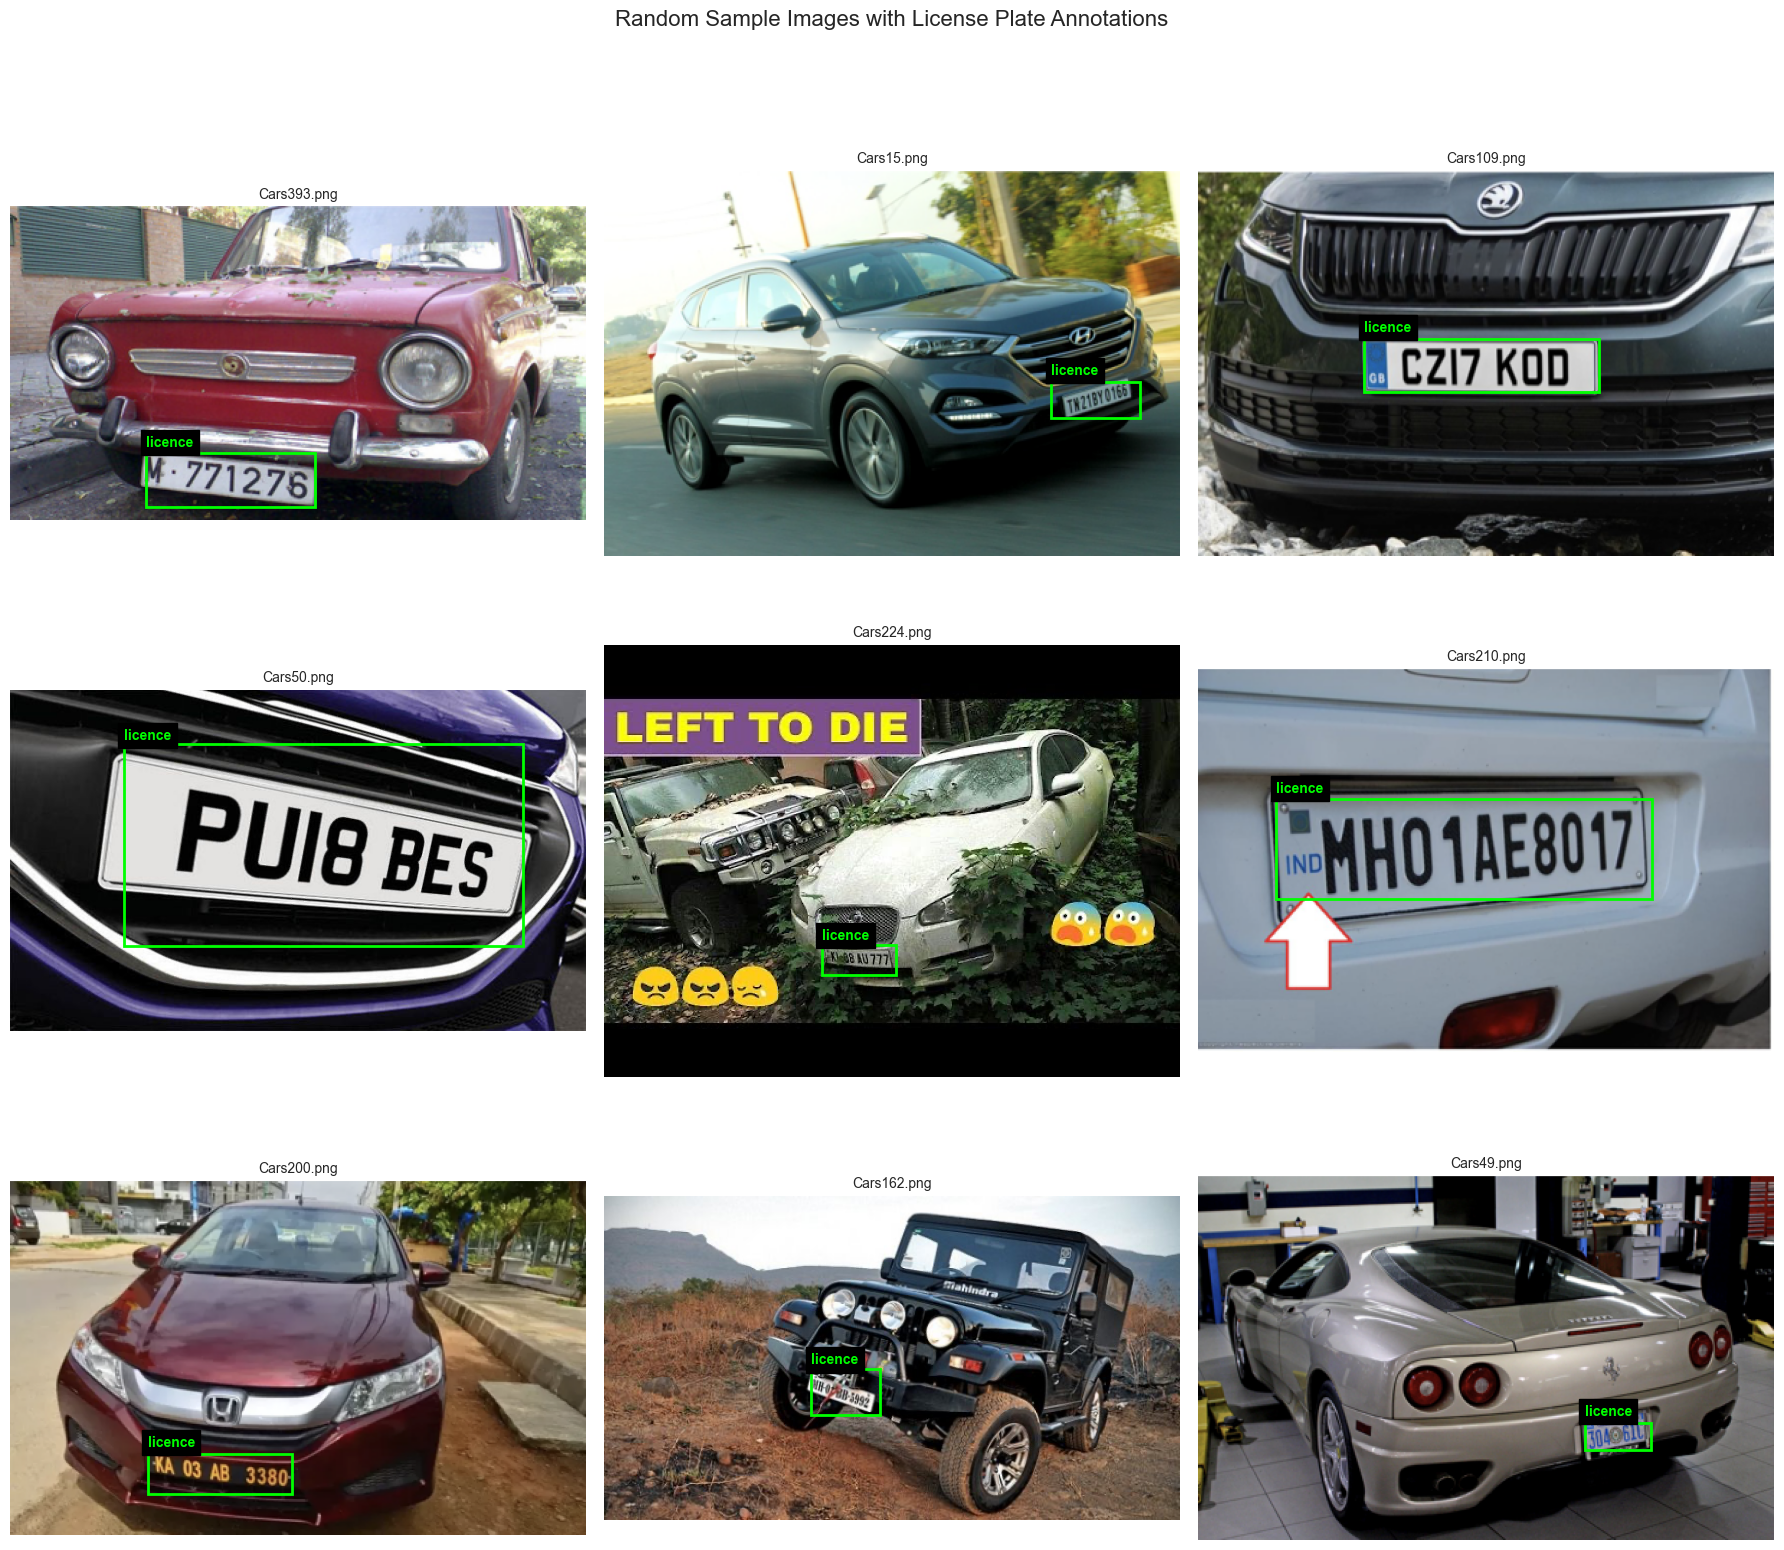

Saved to results/sample_images.png


In [19]:
def plot_image_with_boxes(image_path, boxes, ax=None):
    """Display an image with its bounding boxes."""
    img = Image.open(image_path)
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    ax.imshow(img)
    
    for box in boxes:
        rect = patches.Rectangle(
            (box['xmin'], box['ymin']),
            box['box_width'], box['box_height'],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            box['xmin'], box['ymin'] - 5,
            box['label'], color='lime', fontsize=10,
            fontweight='bold', backgroundcolor='black'
        )
    
    ax.set_title(os.path.basename(image_path), fontsize=10)
    ax.axis('off')

# Show 9 random samples
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
sample_indices = random.sample(range(len(all_annotations)), 9)

for idx, ax in zip(sample_indices, axes.flatten()):
    annot = all_annotations[idx]
    
    # Try to find the matching image file
    img_name = annot['filename']
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    if not os.path.exists(img_path):
        # Try common extensions
        base = os.path.splitext(img_name)[0]
        for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG']:
            candidate = os.path.join(IMAGE_DIR, base + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
    
    if os.path.exists(img_path):
        plot_image_with_boxes(img_path, annot['boxes'], ax)
    else:
        ax.text(0.5, 0.5, f'Image not found:\n{img_name}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(img_name, fontsize=10)

plt.suptitle('Random Sample Images with License Plate Annotations', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/sample_images.png')

## 6. Analyze Image Dimensions

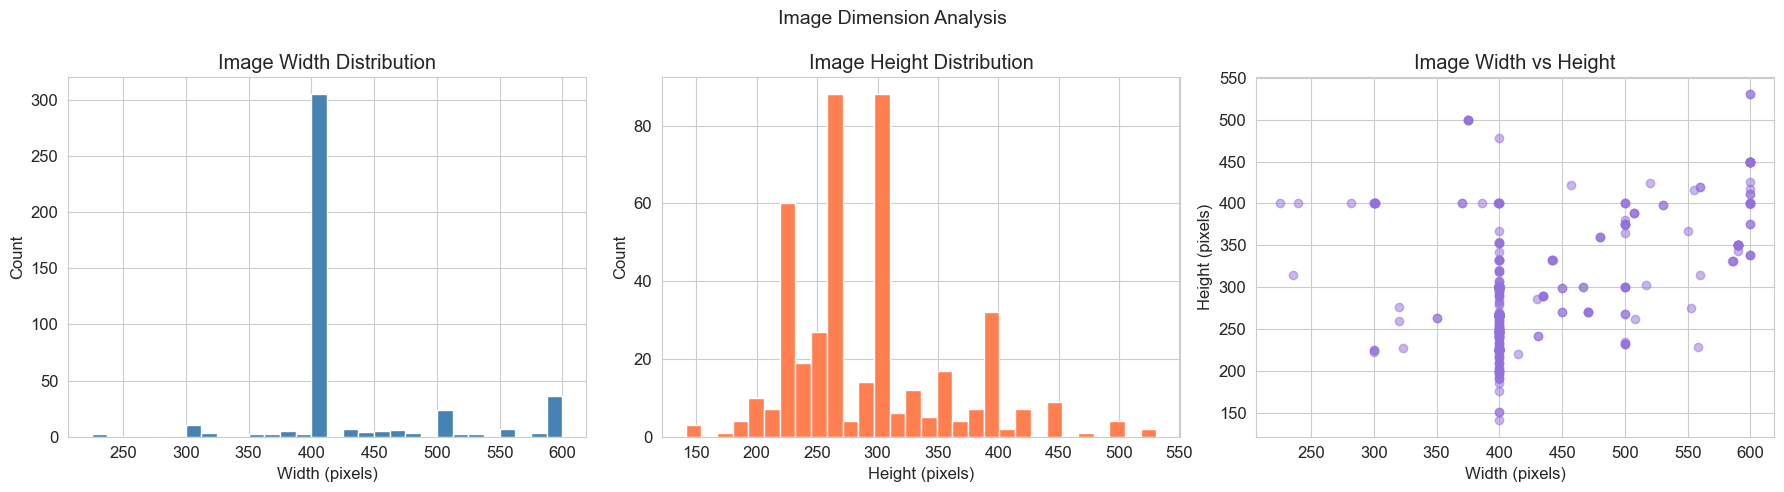

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Image width distribution
axes[0].hist(df_images['width'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

# Image height distribution
axes[1].hist(df_images['height'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')

# Width vs Height scatter
axes[2].scatter(df_images['width'], df_images['height'], alpha=0.5, color='mediumpurple')
axes[2].set_title('Image Width vs Height')
axes[2].set_xlabel('Width (pixels)')
axes[2].set_ylabel('Height (pixels)')

plt.suptitle('Image Dimension Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../results/image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyze Bounding Box Statistics

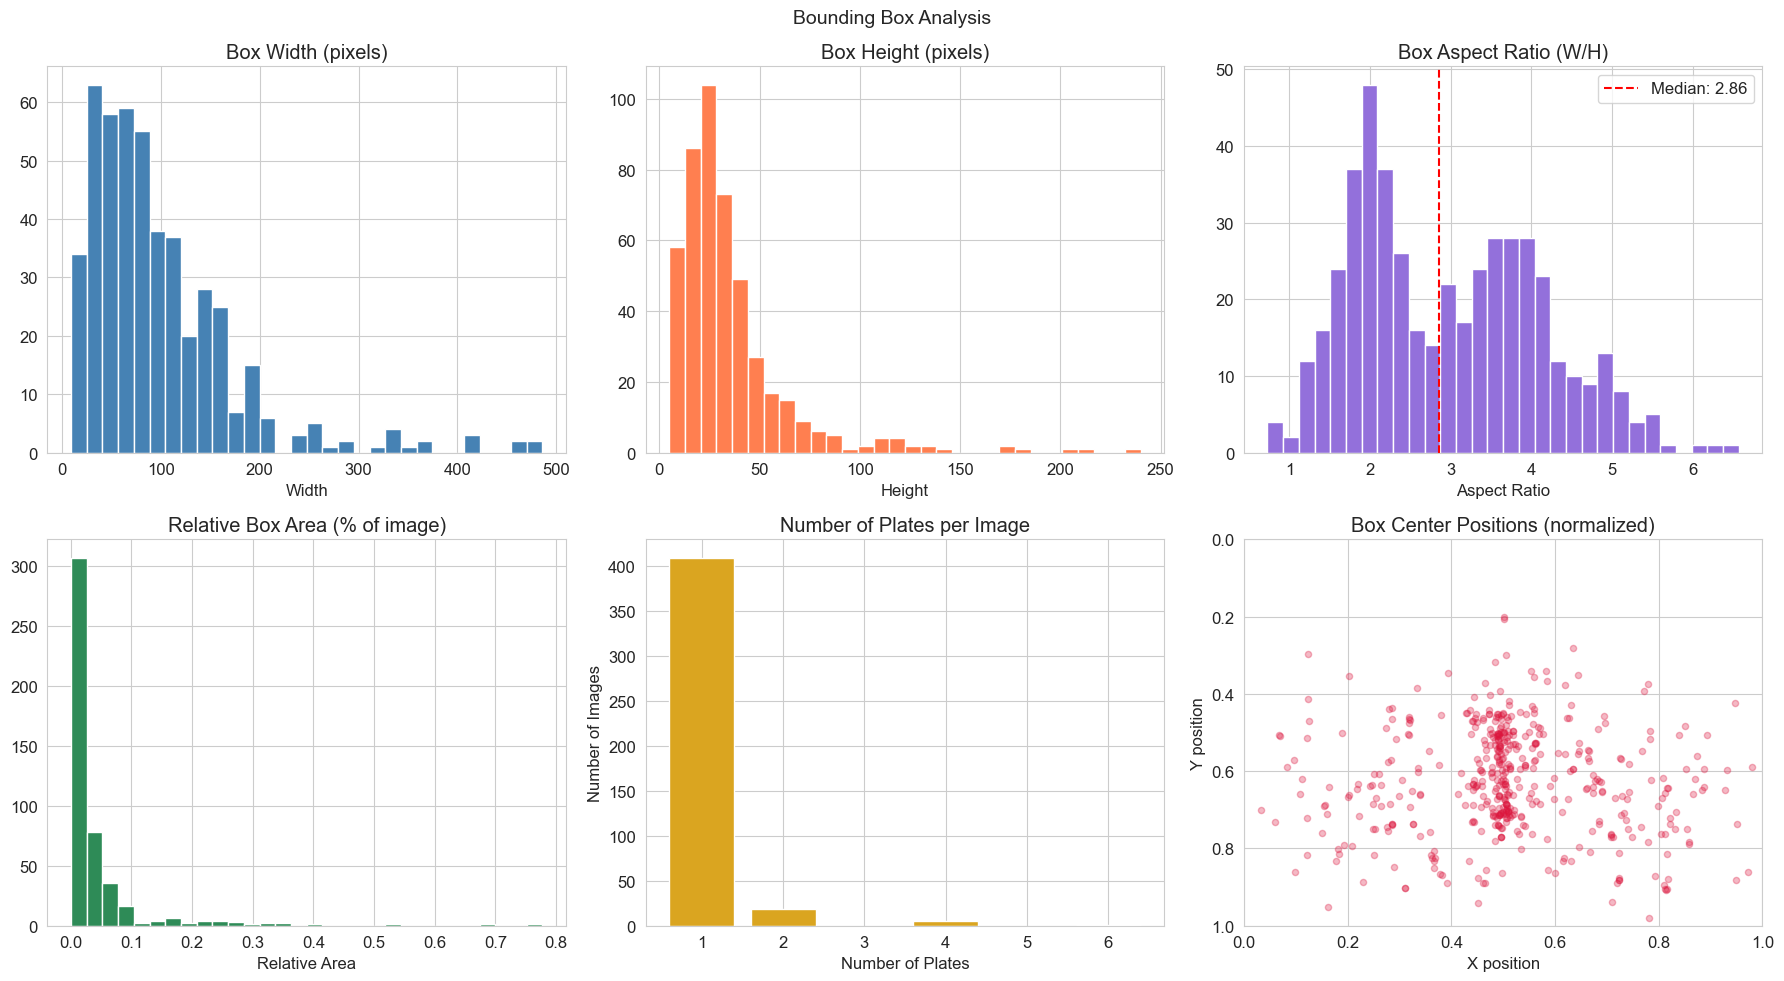

In [21]:
# Add relative size columns (box size relative to image size)
df_boxes['rel_width'] = df_boxes['box_width'] / df_boxes['img_width']
df_boxes['rel_height'] = df_boxes['box_height'] / df_boxes['img_height']
df_boxes['rel_area'] = df_boxes['rel_width'] * df_boxes['rel_height']
df_boxes['aspect_ratio'] = df_boxes['box_width'] / df_boxes['box_height']
df_boxes['center_x'] = ((df_boxes['xmin'] + df_boxes['xmax']) / 2) / df_boxes['img_width']
df_boxes['center_y'] = ((df_boxes['ymin'] + df_boxes['ymax']) / 2) / df_boxes['img_height']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Box width distribution
axes[0, 0].hist(df_boxes['box_width'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Box Width (pixels)')
axes[0, 0].set_xlabel('Width')

# Box height distribution
axes[0, 1].hist(df_boxes['box_height'], bins=30, color='coral', edgecolor='white')
axes[0, 1].set_title('Box Height (pixels)')
axes[0, 1].set_xlabel('Height')

# Aspect ratio
axes[0, 2].hist(df_boxes['aspect_ratio'], bins=30, color='mediumpurple', edgecolor='white')
axes[0, 2].set_title('Box Aspect Ratio (W/H)')
axes[0, 2].set_xlabel('Aspect Ratio')
axes[0, 2].axvline(x=df_boxes['aspect_ratio'].median(), color='red', linestyle='--', label=f'Median: {df_boxes["aspect_ratio"].median():.2f}')
axes[0, 2].legend()

# Relative area
axes[1, 0].hist(df_boxes['rel_area'], bins=30, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Relative Box Area (% of image)')
axes[1, 0].set_xlabel('Relative Area')

# Number of boxes per image
box_counts = df_images['num_boxes'].value_counts().sort_index()
axes[1, 1].bar(box_counts.index, box_counts.values, color='goldenrod', edgecolor='white')
axes[1, 1].set_title('Number of Plates per Image')
axes[1, 1].set_xlabel('Number of Plates')
axes[1, 1].set_ylabel('Number of Images')

# Box center positions (heatmap-like scatter)
axes[1, 2].scatter(df_boxes['center_x'], df_boxes['center_y'], alpha=0.3, s=20, color='crimson')
axes[1, 2].set_title('Box Center Positions (normalized)')
axes[1, 2].set_xlabel('X position')
axes[1, 2].set_ylabel('Y position')
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(1, 0)  # Flip y-axis to match image coordinates

plt.suptitle('Bounding Box Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../results/bbox_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Box Size Heatmap (where are plates located in images?)

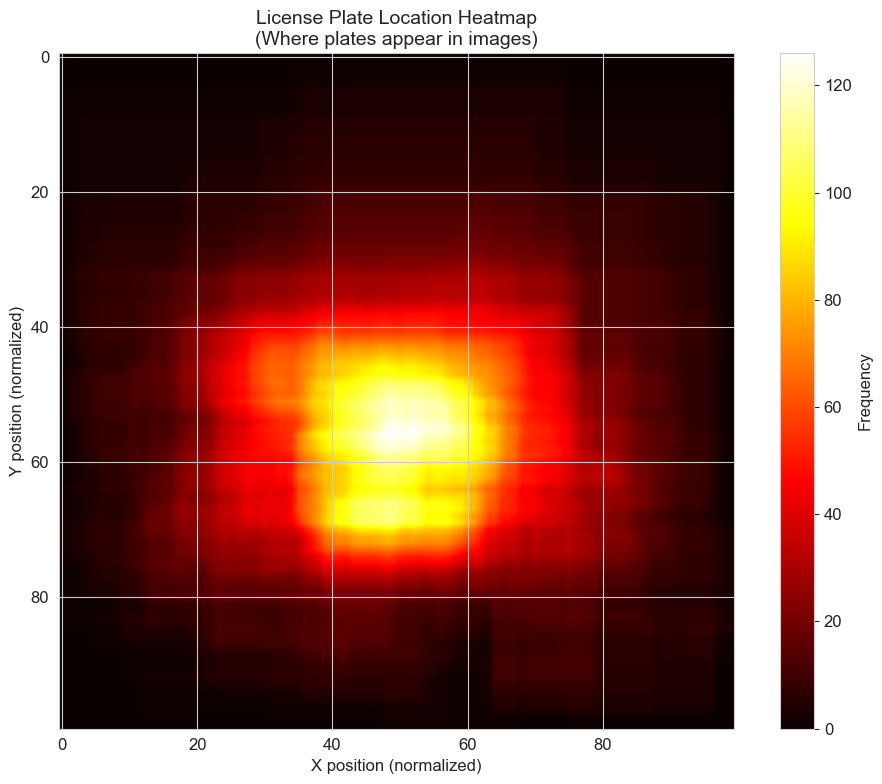

In [22]:
# Create a heatmap of where bounding boxes tend to appear
heatmap = np.zeros((100, 100))

for _, box in df_boxes.iterrows():
    # Normalize coordinates to 0-99 grid
    x1 = int(box['xmin'] / box['img_width'] * 99)
    y1 = int(box['ymin'] / box['img_height'] * 99)
    x2 = int(box['xmax'] / box['img_width'] * 99)
    y2 = int(box['ymax'] / box['img_height'] * 99)
    
    x1, x2 = max(0, x1), min(99, x2)
    y1, y2 = max(0, y1), min(99, y2)
    
    heatmap[y1:y2+1, x1:x2+1] += 1

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(heatmap, cmap='hot', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Frequency')
ax.set_title('License Plate Location Heatmap\n(Where plates appear in images)', fontsize=14)
ax.set_xlabel('X position (normalized)')
ax.set_ylabel('Y position (normalized)')
plt.tight_layout()
plt.savefig('../results/plate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Identify Challenges & Key Observations

In [23]:
# Compute summary statistics for the report
print('=' * 60)
print('KEY OBSERVATIONS & CHALLENGES')
print('=' * 60)

# 1. Dataset size
print(f'\n1. DATASET SIZE')
print(f'   - {len(df_images)} images is relatively SMALL for deep learning')
print(f'   - Data augmentation will be critical')

# 2. Image size variability
print(f'\n2. IMAGE SIZE VARIABILITY')
unique_sizes = df_images.groupby(['width', 'height']).size()
print(f'   - {len(unique_sizes)} unique image dimensions')
print(f'   - Will need resizing/padding for model input')

# 3. Bounding box sizes
small_boxes = (df_boxes['rel_area'] < 0.01).sum()
large_boxes = (df_boxes['rel_area'] > 0.1).sum()
print(f'\n3. BOUNDING BOX SIZES')
print(f'   - Very small plates (<1% of image): {small_boxes} ({small_boxes/len(df_boxes)*100:.1f}%)')
print(f'   - Large plates (>10% of image):     {large_boxes} ({large_boxes/len(df_boxes)*100:.1f}%)')
print(f'   - Mean aspect ratio: {df_boxes["aspect_ratio"].mean():.2f}')

# 4. Multiple plates
multi_plate = (df_images['num_boxes'] > 1).sum()
print(f'\n4. MULTIPLE PLATES PER IMAGE')
print(f'   - Images with >1 plate: {multi_plate} ({multi_plate/len(df_images)*100:.1f}%)')

# 5. Class labels
print(f'\n5. CLASS LABELS')
print(f'   - Labels found: {df_boxes["label"].unique()}')
print(f'   - Label distribution:')
print(df_boxes['label'].value_counts().to_string())

print(f'\n{"=" * 60}')
print('RECOMMENDATIONS FOR TRAINING')
print('=' * 60)
print('1. Use heavy data augmentation (flips, rotations, color jitter)')
print('2. Consider anchor box tuning based on plate aspect ratios')
print('3. Use transfer learning (pretrained backbones)')
print('4. Monitor for overfitting due to small dataset size')
print('5. Use proper train/val/test split (e.g., 70/15/15)')

KEY OBSERVATIONS & CHALLENGES

1. DATASET SIZE
   - 433 images is relatively SMALL for deep learning
   - Data augmentation will be critical

2. IMAGE SIZE VARIABILITY
   - 128 unique image dimensions
   - Will need resizing/padding for model input

3. BOUNDING BOX SIZES
   - Very small plates (<1% of image): 143 (30.4%)
   - Large plates (>10% of image):     34 (7.2%)
   - Mean aspect ratio: 2.96

4. MULTIPLE PLATES PER IMAGE
   - Images with >1 plate: 24 (5.5%)

5. CLASS LABELS
   - Labels found: ['licence']
   - Label distribution:
label
licence    471

RECOMMENDATIONS FOR TRAINING
1. Use heavy data augmentation (flips, rotations, color jitter)
2. Consider anchor box tuning based on plate aspect ratios
3. Use transfer learning (pretrained backbones)
4. Monitor for overfitting due to small dataset size
5. Use proper train/val/test split (e.g., 70/15/15)


## 10. Summary Statistics Table

In [24]:
summary = {
    'Metric': [
        'Total Images', 'Total Bounding Boxes', 'Unique Labels',
        'Avg Boxes per Image', 'Max Boxes per Image',
        'Avg Image Width', 'Avg Image Height',
        'Avg Box Width (px)', 'Avg Box Height (px)',
        'Avg Box Aspect Ratio', 'Avg Relative Box Area'
    ],
    'Value': [
        len(df_images), len(df_boxes), len(df_boxes['label'].unique()),
        f"{df_images['num_boxes'].mean():.2f}", df_images['num_boxes'].max(),
        f"{df_images['width'].mean():.0f}", f"{df_images['height'].mean():.0f}",
        f"{df_boxes['box_width'].mean():.0f}", f"{df_boxes['box_height'].mean():.0f}",
        f"{df_boxes['aspect_ratio'].mean():.2f}", f"{df_boxes['rel_area'].mean():.4f}"
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Save summary to CSV
df_summary.to_csv('../results/dataset_summary.csv', index=False)
print('\nSaved summary to results/dataset_summary.csv')

               Metric  Value
         Total Images    433
 Total Bounding Boxes    471
        Unique Labels      1
  Avg Boxes per Image   1.09
  Max Boxes per Image      6
      Avg Image Width    425
     Avg Image Height    292
   Avg Box Width (px)     98
  Avg Box Height (px)     35
 Avg Box Aspect Ratio   2.96
Avg Relative Box Area 0.0405

Saved summary to results/dataset_summary.csv


---
## Next Steps

Now that we understand the dataset, in the next notebook (`02_data_preprocessing.ipynb`) we will:
1. Create train/validation/test splits
2. Convert annotations to YOLO format
3. Convert annotations to COCO format (for Faster R-CNN & RetinaNet)
4. Set up data augmentation pipelines